In [155]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str,
    format_model_str_word_task,
    format_model_str_nsynth,
    normalize_model_list,
    normalize_model_name,
    normalize_palette_dict,
    marker_palette_for_hue,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    get_plot_groups,
    model_label,
    plot_grouped_bars,
)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re



## Get ESC 50 results for each model

In [78]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("*resnet*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("word_kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("config_linear*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("byola*/saved_vars*.pickle"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.parent.stem.startswith('kell2018'):
        if 'eq_lmbda' in path_str:
            # if 'fixed_loss' not in path_str:
            continue 
    
    if "resnet18" in path_str:
        if "barlow" in path_str:
            if "invar_augment" not in path_str and "audioset" not in path_str:
                continue
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))

    df_list.append(data)

esc_50_df = pd.DataFrame.from_records(df_list)
esc_50_df['test_layer'] = esc_50_df['test_layer'].astype('str')
esc_50_df['model_name'] = esc_50_df['model_name'].apply(normalize_model_name)

esc_50_df = esc_50_df.loc[esc_50_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [79]:


esc_50_df.model_name.unique()

array(['CochDNN9 supervised word', 'CochDNN9 ssl λ=0.1',
       'CochDNN9 ssl λ=0.0', 'CochDNN9 ssl λ=0.5', 'resnet18 ssl λ=0.0',
       'resnet18 ssl λ=1.0', 'CochDNN9 supervised multi-task',
       'CochDNN9 ssl dual λ=0.0', 'CochDNN9 ssl λ=0.4',
       'CochDNN9 ssl dual λ=0.5', 'CochDNN9 ssl λ=0.2',
       'CochDNN9 ssl λ=0.8', 'CochDNN9 ssl λ=0.3', 'resnet18 ssl λ=0.01',
       'resnet18 ssl λ=0.5', 'resnet18 ssl λ=0.1', 'resnet18 ssl λ=0.4',
       'resnet18 ssl λ=0.3', 'resnet18 ssl λ=0.2',
       'CochDNN9 supervised audioset', 'CochDNN9 ssl λ=1.0',
       'CochDNN9 ssl dual λ=0.1', 'CochDNN9 scaled ssl λ=0.5',
       'CochDNN9 ssl dual λ=0.01', 'CochDNN9 scaled supervised',
       'CochDNN9 scaled ssl λ=0.0',
       'CochDNN9 ssl dual λ=0.0 unpaired augs', 'resnet50 ssl λ=0.5',
       'resnet50 scaled ssl λ=0.5', 'resnet18 scaled ssl λ=0.0',
       'resnet18 scaled ssl λ=0.5', 'resnet18 supervised audioset',
       'resnet50 supervised word', 'resnet50 ssl λ=0.0',
       'resn

## Get speech commands task results

In [80]:
path_to_speech_commands_results = Path("eval_jsin_results/linear_eval_speech_commands")
kell2018_speech_commands_results = list(path_to_speech_commands_results.rglob("*kell2018*full*cosine*.pkl"))
kell2018_speech_commands_results = [path for path in kell2018_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'mmcr']])]

resnet18_speech_commands_results = list(path_to_speech_commands_results.rglob("resnet18*.pkl"))
resnet18_speech_commands_results = [path for path in resnet18_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop']])]

byola_results =  list(path_to_speech_commands_results.rglob("config_*cosine*.pkl"))

all_speech_commands_task_results = kell2018_speech_commands_results + resnet18_speech_commands_results + byola_results

df_list = []

for i, results_path in enumerate(all_speech_commands_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if "resnet18" in path_str:
        if "barlow" in path_str and "invar_augment" not in path_str:
            continue
    if "equivariant" in path_str and not "cosine" in path_str:
        continue 


    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, _, eq_lmbda = format_model_str_word_task(results_path)
    if arch_class == 'unknown' and 'config_' in path_str:
        model_name = 'byol-a'
        arch_class = 'byol-a'
        eq_lmbda = ''
    
    # Remove audioset modifiers before normalization if we have explicit eq_lmbda
    # to prevent normalize_model_name from adding another lambda
    if eq_lmbda and 'ssl' in model_name:
        model_name = re.sub(
            r'\s+(?:jsin\s+)?audioset|\s+unbalanced\s+audioset',
            '',
            model_name,
        )
        model_name = re.sub(r'\s{2,}', ' ', model_name).strip()
    
    # Normalize the model name
    model_name = normalize_model_name(model_name)
    
    test_layer = path_str.split('AdamW_')[-1].split('_')[0]
    if model_name == 'byol-a':
        test_layer = 'final'

    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}


    df_list.append(data)

speech_commands_df = pd.DataFrame.from_records(df_list)
speech_commands_df['test_layer'] = speech_commands_df['test_layer'].astype('str')
speech_commands_df['task'] = '20-word classification'

## Get word task results 

In [81]:
path_to_word_results = Path("eval_jsin_results")
kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
# kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet18_word_results = list(path_to_word_results.rglob("*resnet18*.pkl"))
resnet18_word_results = [path for path in resnet18_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet50_word_results = list(path_to_word_results.rglob("*resnet50*.pkl"))
resnet50_word_results = [path for path in resnet50_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

byola_results =  list(path_to_word_results.rglob("config_linear*.pkl"))
byola_results = [path for path in byola_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

byola_results_new =  list(path_to_word_results.rglob("byola*.pkl"))
byola_results += [path for path in byola_results_new if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

all_word_task_results = kell2018_word_results + resnet18_word_results + resnet50_word_results + byola_results

df_list = []

for i, results_path in enumerate(all_word_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if 'kell2018' in path_str and not 'w_dropout_center_eval_words' in path_str:

        continue
    if "resnet18" in path_str:
        if "barlow" in path_str and "invar_augment" not in path_str:
            continue
    if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order]):

        continue 

    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_word_task(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}


    df_list.append(data)

word_df = pd.DataFrame.from_records(df_list)
word_df['test_layer'] = word_df['test_layer'].astype('str')
word_df['model_name'] = word_df['model_name'].apply(normalize_model_name)
word_df['task'] = '800-word classification'

In [82]:
word_df.model_name.unique()

array(['CochDNN9 ssl λ=0.5', 'CochDNN9 ssl dual λ=0.0 unpaired augs',
       'CochDNN9 ssl dual λ=0.01', 'CochDNN9 supervised word',
       'CochDNN9 ssl λ=0.3', 'CochDNN9 ssl λ=0.1', 'CochDNN9 ssl λ=0.4',
       'CochDNN9 ssl λ=0.2', 'CochDNN9 supervised multi-task',
       'CochDNN9 scaled ssl λ=0.0', 'CochDNN9 scaled ssl λ=0.5',
       'CochDNN9 supervised audioset', 'CochDNN9 ssl λ=0.0',
       'CochDNN9 ssl dual λ=0.5', 'CochDNN9 ssl dual λ=0.1',
       'CochDNN9 scaled supervised', 'CochDNN9 ssl λ=1.0',
       'CochDNN9 ssl dual λ=0.0', 'resnet18 ssl λ=0.5',
       'resnet18 ssl λ=0.1', 'resnet18 ssl λ=0.3', 'resnet18 ssl λ=0.0',
       'resnet18 ssl λ=0.4', 'resnet18 ssl λ=0.2', 'resnet18 ssl λ=0.01',
       'resnet18 ssl λ=1.0', 'resnet50 scaled ssl λ=0.5', 'byol-a',
       'byol-a λ=0.0'], dtype=object)

In [83]:
path_to_nsynth_results = Path("eval_nsynth_results")

all_model_results = list(path_to_nsynth_results.rglob("audioset_*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("resnet18_barlow*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("resnet50_barlow*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("word_kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("config_*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("byola*nsynth*.pkl"))

df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    results = pd.read_pickle(results_path)
    overall_acc = results['top1_mean']
    # Get error if available
    top1_sem = results.get('top1_sem', None)

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_nsynth(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if top1_sem is not None:
        data['top1_sem'] = top1_sem

    df_list.append(data)

nsynth_df = pd.DataFrame.from_records(df_list)
nsynth_df['test_layer'] = nsynth_df['test_layer'].astype('str')
nsynth_df['model_name'] = nsynth_df['model_name'].apply(normalize_model_name)
nsynth_df['task'] = 'NSynth'
nsynth_df = nsynth_df.loc[nsynth_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [84]:
nsynth_df

,model_name,arch_class,test_layer,eq_lmbda,overall_acc,top1_sem,task
0,CochDNN9 supervised audioset,kell2018,relu4,,0.661865,0.048088,NSynth
1,CochDNN9 ssl λ=0.4,kell2018,relu4,0.4,0.659424,0.056745,NSynth
2,CochDNN9 ssl λ=0.5,kell2018,relu4,0.5,0.636719,0.047065,NSynth
3,CochDNN9 scaled ssl λ=0.5,kell2018,relu4,0.5,0.701172,0.050116,NSynth
4,CochDNN9 ssl λ=0.0,kell2018,relu4,0.0,0.684326,0.043880,NSynth
5,CochDNN9 ssl λ=0.2,kell2018,relu4,0.2,0.683838,0.048440,NSynth
6,CochDNN9 scaled supervised,kell2018,relu4,,0.713135,0.042431,NSynth
7,CochDNN9 scaled ssl λ=0.0,kell2018,relu4,0.0,0.700195,0.050310,NSynth
8,CochDNN9 supervised multi-task,kell2018,relu4,,0.691162,0.054567,NSynth
9,CochDNN9 ssl λ=0.3,kell2018,relu4,0.3,0.674072,0.048092,NSynth


In [85]:
df = pd.concat([esc_50_df, speech_commands_df, word_df, nsynth_df], axis=0, ignore_index=True)
df.head()

,model_name,arch_class,test_layer,eq_lmbda,overall_acc,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem,task,speaker_top1_mean,speaker_top1_sem,speaker_top5_mean,speaker_top5_sem,top1_sem
0,CochDNN9 supervised word,kell2018,preproc,,0.2480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CochDNN9 ssl λ=0.1,kell2018,preproc,0.1,0.2480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CochDNN9 ssl λ=0.0,kell2018,preproc,,0.2485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CochDNN9 ssl λ=0.5,kell2018,preproc,0.5,0.2485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,resnet18 ssl λ=0.0,resnet18,preproc,0.0,0.2485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Plot Task results

### Make main figure plot with supervised models as reflines

In [86]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
marker_palette = marker_palette_for_hue(hue_order)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

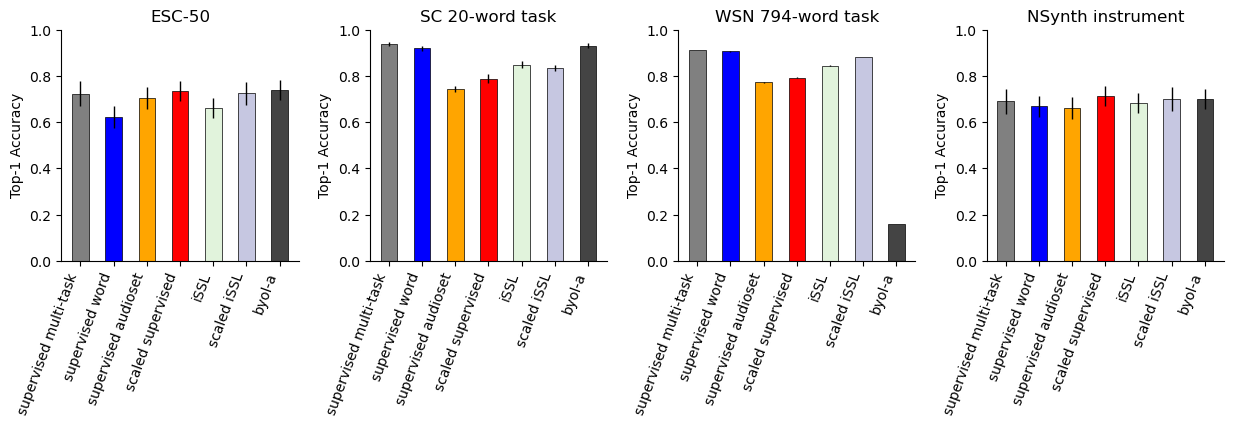

In [117]:
# Helper function to filter models (supervised, SSL λ=0, scaled SSL λ=0, byol-a)
def filter_models_for_plot(df):
    """Filter to only supervised, SSL λ=0 (both regular and scaled), and byol-a models"""
    mask = (
        # Supervised models
        (df['model_name'].str.contains('supervised', na=False)) |
        # SSL with lambda = 0 (both regular and scaled)
        ((df['model_name'].str.contains('ssl', na=False)) & 
         ((df['eq_lmbda'] == '0.0') | (df['eq_lmbda'] == '') | (df['eq_lmbda'].isna()))) |
        # byol-a
        (df['model_name'] == 'byol-a')
    )
    return df[mask]

# Helper function to get custom label for models
def get_custom_label(model, eq_lmbda=None):
    """Get custom label for models, with special handling for SSL λ=0"""
    label = model_label(model)
    
    # Check if this is SSL λ=0 (regular) - check both model name and eq_lmbda
    is_ssl_lambda_0 = False
    if model.startswith('CochDNN9 ssl '):
        if 'scaled' not in model:
            # Check if lambda is 0 based on model name or eq_lmbda parameter
            if eq_lmbda in ['0.0', '', None] or 'λ=0.0' in model or 'λ=0' in model:
                is_ssl_lambda_0 = True
    
    if is_ssl_lambda_0:
        return 'iSSL'
    
    # Check if this is scaled SSL λ=0
    if model.startswith('CochDNN9 scaled ssl '):
        if eq_lmbda in ['0.0', '', None] or 'λ=0.0' in model or 'λ=0' in model:
            return 'scaled iSSL'
    
    return label

# Helper function to create simple bar plot (not grouped)
def plot_simple_bars(ax, data, value_col, title, ylabel, hue_order=None, hue_dict=None):
    """Create simple bar plot with individual bars for each model"""
    if hue_order is None:
        hue_order = get_standard_hue_order()
    if hue_dict is None:
        base_colors = get_standard_base_colors()
        hue_dict = build_model_palette(hue_order, base_colors)
    
    # Get means for each model
    means = data.groupby('model_name', as_index=True)[value_col].mean()
    
    # Also get eq_lmbda for each model (for label customization)
    eq_lmbda_dict = data.groupby('model_name', as_index=True)['eq_lmbda'].first().to_dict()
    
    # Determine error column name based on value_col
    if value_col == 'word_top1_mean':
        error_col = 'word_top1_sem'
    elif value_col == 'overall_acc':
        # Try different possible error column names for overall_acc
        if 'top1_sem' in data.columns:
            error_col = 'top1_sem'
        elif 'overall_acc_sem' in data.columns:
            error_col = 'overall_acc_sem'
        else:
            error_col = None
    else:
        error_col = None
    
    # Get error values if error column exists
    errors = None
    if error_col is not None and error_col in data.columns:
        errors = data.groupby('model_name', as_index=True)[error_col].mean()
        # Filter and reindex to match means
        errors = errors[errors.index.isin(hue_order)]
        model_order = [m for m in hue_order if m in means.index]
        errors = errors.reindex(model_order)
    
    # Filter to only models in hue_order
    means = means[means.index.isin(hue_order)]
    
    # Sort by model order in hue_order
    model_order = [m for m in hue_order if m in means.index]
    means = means.reindex(model_order)
    
    # Create bars
    # Space bars closer together (0.6 units apart instead of 1.0)
    x_pos = np.arange(len(means)) * 1
    bar_width = 0.5
    
    legend_handles = []
    legend_labels = []
    
    for i, (model, value) in enumerate(means.items()):
        color = hue_dict.get(model, '#444444')
        eq_lmbda = eq_lmbda_dict.get(model, None)
        label = get_custom_label(model, eq_lmbda)
        
        # Get error for this model if available
        yerr_val = None
        if errors is not None and model in errors.index:
            yerr_val = errors.loc[model]
        
        bar = ax.bar(x_pos[i], value, width=bar_width, color=color, 
                     edgecolor='black', linewidth=0.5, label=label, alpha=1,
                     yerr=yerr_val, capsize=0, error_kw={'linewidth': 1, 'capthick': 1})
        legend_handles.append(bar[0])
        legend_labels.append(label)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([get_custom_label(m, eq_lmbda_dict.get(m, None)) for m in model_order], rotation=70, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    # ax.grid(axis='y', alpha=0.3, zorder=-1)
    
    return legend_handles, legend_labels

# Combine all dataframes for filtering
all_data = pd.concat([df, nsynth_df], axis=0, ignore_index=True)

# Filter to only models we want
filtered_data = filter_models_for_plot(all_data)

# Focus on relu4 layers only (as before)
# Exclude dual task models from ESC-50 and WSN plots
esc_50_to_plot = filtered_data[~filtered_data.overall_acc.isna() & ((filtered_data.test_layer.str.contains('relu4')) | ((filtered_data.model_name == 'byol-a') & (filtered_data.test_layer.str.contains('final')))) & ~filtered_data.model_name.str.contains('dual', na=False)]
speech_commands_to_plot = filtered_data[~filtered_data.word_top1_mean.isna() & (filtered_data.task == '20-word classification') & ((filtered_data.test_layer.str.contains('relu4')) | ((filtered_data.model_name == 'byol-a') & (filtered_data.test_layer.str.contains('final'))))]
word_to_plot = filtered_data[~filtered_data.word_top1_mean.isna() & (filtered_data.task == '800-word classification') & ((filtered_data.test_layer.str.contains('relu4')) | ((filtered_data.model_name == 'byol-a') & (filtered_data.test_layer.str.contains('final')))) & ~filtered_data.model_name.str.contains('dual', na=False)]
nsynth_to_plot = filtered_data[~filtered_data.overall_acc.isna() & (filtered_data.task == 'NSynth') & ((filtered_data.test_layer.str.contains('relu4')) | ((filtered_data.model_name == 'byol-a') & (filtered_data.test_layer.str.contains('final'))))]

# Get model groups (for legend handling)
supervised_names, ssl_names, scaled_ssl_names, byol_names = get_model_groups(hue_order)

fig, axes = plt.subplots(1, 4, figsize=(15, 3))

esc_handles, esc_labels = plot_simple_bars(
    axes[0],
    esc_50_to_plot,
    value_col='overall_acc',
    title='ESC-50',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

speech_commands_handles, speech_commands_labels = plot_simple_bars(
    axes[1],
    speech_commands_to_plot,
    value_col='word_top1_mean',
    title='SC 20-word task',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

word_handles, word_labels = plot_simple_bars(
    axes[2],
    word_to_plot,
    value_col='word_top1_mean',
    title='WSN 794-word task',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

nsynth_handles, nsynth_labels = plot_simple_bars(
    axes[3],
    nsynth_to_plot,
    value_col='overall_acc',
    title='NSynth instrument',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

axes[0].set_ylim(0, 1.0)
axes[1].set_ylim(0, 1.0)
axes[2].set_ylim(0, 1.0)
axes[3].set_ylim(0, 1.0)

sns.despine()
plt.subplots_adjust(wspace=0.3)
# plt.tight_layout()
# plt.show()

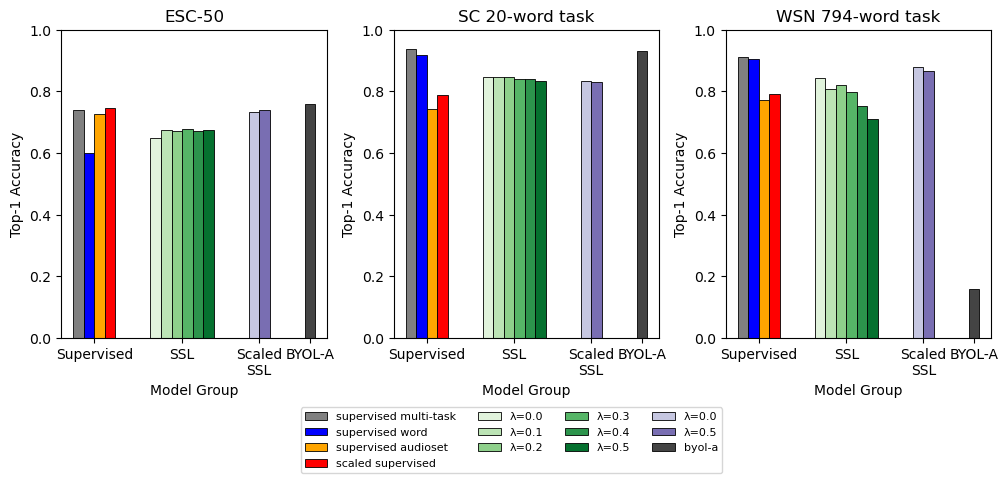

In [95]:

# Focus on relu layers only (as before)
esc_50_to_plot = df[~df.overall_acc.isna() & ((df.test_layer.str.contains('relu4')) | ((df.model_name == 'byol-a') & (df.test_layer.str.contains('final'))))]
speech_commands_to_plot = df[~df.word_top1_mean.isna() & (df.task == '20-word classification') & ((df.test_layer.str.contains('relu4')) | ((df.model_name == 'byol-a') & (df.test_layer.str.contains('final'))))]
word_to_plot = df[~df.word_top1_mean.isna() & (df.task == '800-word classification') & ((df.test_layer.str.contains('relu4')) | ((df.model_name == 'byol-a') & (df.test_layer.str.contains('final'))))]

# Get model groups (for legend handling)
supervised_names, ssl_names, scaled_ssl_names, byol_names = get_model_groups(hue_order)


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

esc_handles, esc_labels = plot_grouped_bars(
    axes[0],
    esc_50_to_plot,
    value_col='overall_acc',
    title='ESC-50',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

speech_commands_handles, speech_commands_labels = plot_grouped_bars(
    axes[1],
    speech_commands_to_plot,
    value_col='word_top1_mean',
    title='SC 20-word task',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

word_handles, word_labels = plot_grouped_bars(
    axes[2],
    word_to_plot,
    value_col='word_top1_mean',
    title='WSN 794-word task',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)
axes[0].set_ylim(0, 1.0)
axes[1].set_ylim(0, 1.0)
axes[2].set_ylim(0, 1.0)

# Build a single legend shared across all panels
legend_handles = []
legend_labels = []
for handles, labels in [(esc_handles, esc_labels)]:
    for handle, label in zip(handles, labels):
        # if label not in legend_labels:
        legend_handles.append(handle)
        legend_labels.append(label)

# Ensure scaled SSL palette entries appear in legend, even if missing from data
for model in scaled_ssl_names:
    label = model_label(model)
    if label not in legend_labels:
        color = hue_dict.get(model, '#444444')
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(label)

if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
    )

# ax.grid(axis='y', alpha=0.3, zorder=-1)
plt.subplots_adjust(wspace=0.25)
# plt.tight_layout()
# plt.show()

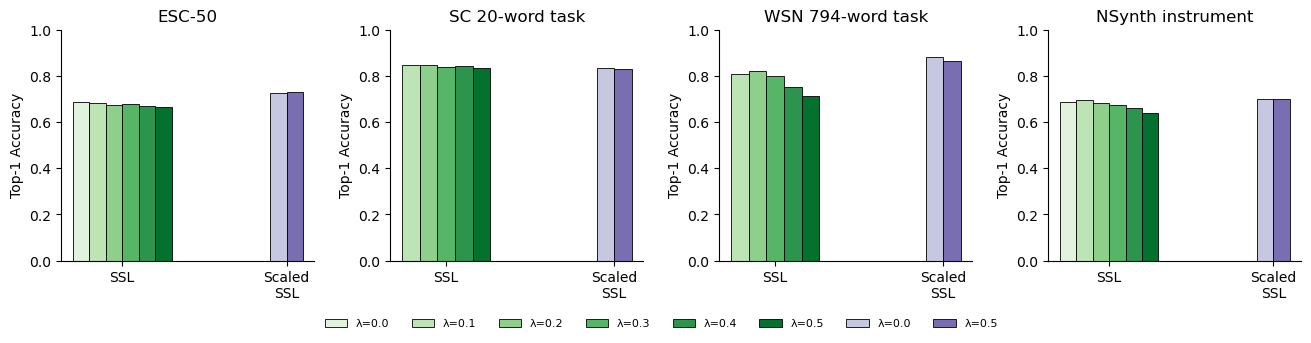

In [164]:

# Helper function to filter models for lambda plot (SSL with non-zero lambda only)
def filter_models_lambda_plot(df):
    """Filter to only SSL models with non-zero lambda values"""
    mask = (
        # SSL with lambda != 0 (both regular and scaled)
        (df['model_name'].str.contains('ssl', na=False)) & 
        (df['eq_lmbda'] != '') & 
        (df['eq_lmbda'] != '0.8') &
        (df['eq_lmbda'].notna())
    )
    return df[mask]

# Combine all dataframes for filtering
all_data = pd.concat([df, nsynth_df], axis=0, ignore_index=True)

# Filter to only lambda models (excluding λ=0)
lambda_data = filter_models_lambda_plot(all_data)

# Focus on relu4 layers only, exclude dual task models from ESC-50 and WSN
esc_50_lambda = lambda_data[~lambda_data.overall_acc.isna() & ((lambda_data.test_layer.str.contains('relu4')) | ((lambda_data.model_name == 'byol-a') & (lambda_data.test_layer.str.contains('final')))) & ~lambda_data.model_name.str.contains('dual', na=False)]
speech_commands_lambda = lambda_data[~lambda_data.word_top1_mean.isna() & (lambda_data.task == '20-word classification') & ((lambda_data.test_layer.str.contains('relu4')) | ((lambda_data.model_name == 'byol-a') & (lambda_data.test_layer.str.contains('final'))))]
word_lambda = lambda_data[~lambda_data.word_top1_mean.isna() & (lambda_data.task == '800-word classification') & ((lambda_data.test_layer.str.contains('relu4')) | ((lambda_data.model_name == 'byol-a') & (lambda_data.test_layer.str.contains('final')))) & ~lambda_data.model_name.str.contains('dual', na=False)]
nsynth_lambda = lambda_data[~lambda_data.overall_acc.isna() & (lambda_data.task == 'NSynth') & ((lambda_data.test_layer.str.contains('relu4')) | ((lambda_data.model_name == 'byol-a') & (lambda_data.test_layer.str.contains('final'))))]

# Get model groups (for legend handling)
supervised_names, ssl_names, scaled_ssl_names, byol_names = get_model_groups(hue_order)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

esc_handles, esc_labels = plot_grouped_bars(
    axes[0],
    esc_50_lambda,
    value_col='overall_acc',
    title='ESC-50',
    ylabel='Top-1 Accuracy',
    xlabel="",
    hue_order=hue_order,
    hue_dict=hue_dict,
    bar_width=0.1,
    group_gap=0.1,  
)

speech_commands_handles, speech_commands_labels = plot_grouped_bars(
    axes[1],
    speech_commands_lambda,
    value_col='word_top1_mean',
    title='SC 20-word task',
    ylabel='Top-1 Accuracy',
    xlabel="",
    hue_order=hue_order,
    hue_dict=hue_dict,
    bar_width=0.1,
    group_gap=0.1,
)

word_handles, word_labels = plot_grouped_bars(
    axes[2],
    word_lambda,
    value_col='word_top1_mean',
    title='WSN 794-word task',
    ylabel='Top-1 Accuracy',
    xlabel="",
    hue_order=hue_order,
    hue_dict=hue_dict,
    bar_width=0.1,
    group_gap=0.1,
)

nsynth_handles, nsynth_labels = plot_grouped_bars(
    axes[3],
    nsynth_lambda,
    value_col='overall_acc',
    title='NSynth instrument',
    ylabel='Top-1 Accuracy',
    xlabel="",
    hue_order=hue_order,
    hue_dict=hue_dict,
    bar_width=0.1,
    group_gap=0.1,
)

axes[0].set_ylim(0, 1.0)
axes[1].set_ylim(0, 1.0)
axes[2].set_ylim(0, 1.0)
axes[3].set_ylim(0, 1.0)

# Build a single legend shared across all panels
legend_handles = []
legend_labels = []
for handles, labels in [(esc_handles, esc_labels)]:
    for handle, label in zip(handles, labels):
        legend_handles.append(handle)
        legend_labels.append(label)

if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=False,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=8,
    )
# fig.text(0.5, -0.1, '', ha='center', va='center', fontsize=12)

sns.despine()
plt.subplots_adjust(wspace=0.3)
# plt.tight_layout()
# plt.show()


/tmp/ipykernel_1055571/2816501026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  esc_50_lambda.loc[esc_50_lambda['model_name'].str.contains('scaled'), 'training_group'] = 'scaled SSL'


<Axes: xlabel='training_group', ylabel='overall_acc'>

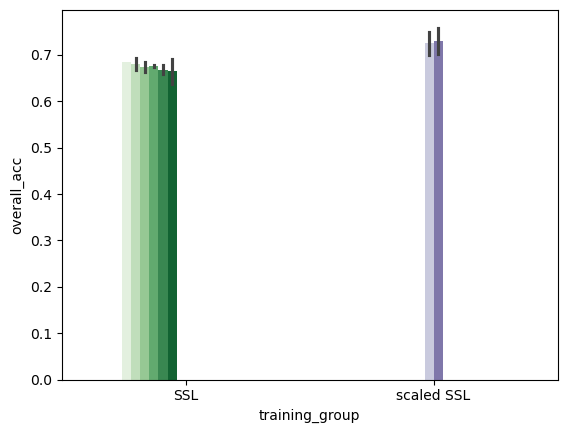

In [135]:
esc_50_lambda = lambda_data[~lambda_data.overall_acc.isna() & ((lambda_data.test_layer.str.contains('relu4')) | ((lambda_data.model_name == 'byol-a') & (lambda_data.test_layer.str.contains('final')))) & ~lambda_data.model_name.str.contains('dual', na=False)]
esc_50_lambda.loc[esc_50_lambda['model_name'].str.contains('scaled'), 'training_group'] = 'scaled SSL'
esc_50_lambda.loc[~esc_50_lambda['model_name'].str.contains('scaled'), 'training_group'] = 'SSL'

sns.barplot(data=esc_50_lambda, x='training_group', y='overall_acc', hue='model_name', palette=hue_dict, hue_order=hue_order, legend=False)


